In [ ]:
import os

# Set Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = 'codingpanda5'  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] = '0c87ee462cdc408e405cd4f933c41ef0' # Replace with your Kaggle API key

# Install Kaggle CLI
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d danielshanbalico/dog-emotion

Dataset URL: https://www.kaggle.com/datasets/danielshanbalico/dog-emotion
License(s): CC0-1.0
dog-emotion.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q /content/dog-emotion.zip

replace Dog Emotion/angry/09dUVMcjCDfOtbeYDQg5Fvu3GPHWJg811.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dog Emotion/angry/0AvKtuzA7LfxnKaO0bey9mQMLnxXad73.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dog Emotion/angry/0C5yo7GxMy8lztxNZvSdfEx2gSPRTR701.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dog Emotion/angry/0C9jEgFQHsh36W5U2u5CA98lB7C5eX806.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
import shutil
import random

# Paths
base_dir = "/content/Dog Emotion"         # CHANGE THIS to your path
output_dir = "/content/split_dog_emotion" # new folder

# Create split folders
splits = ["train", "val", "test"]
classes = ["angry", "happy", "relaxed", "sad"]

for split in splits:
    for cls in classes:
        os.makedirs(f"{output_dir}/{split}/{cls}", exist_ok=True)

# Ratios
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Loop through each class folder
for cls in classes:
    class_folder = os.path.join(base_dir, cls)
    images = os.listdir(class_folder)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy images to split folders
    for img in train_imgs:
        shutil.copy(os.path.join(class_folder, img),
                    f"{output_dir}/train/{cls}/{img}")

    for img in val_imgs:
        shutil.copy(os.path.join(class_folder, img),
                    f"{output_dir}/val/{cls}/{img}")

    for img in test_imgs:
        shutil.copy(os.path.join(class_folder, img),
                    f"{output_dir}/test/{cls}/{img}")

    print(f"{cls}: {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test")

print("Dataset splitting complete!")


angry: 800 train, 100 val, 100 test
happy: 800 train, 100 val, 100 test


In [ ]:
import os
import cv2
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to train folder created earlier
train_dir = "/content/split_dog_emotion/train"
aug_output = "/content/split_dog_emotion/train_augmented"

os.makedirs(aug_output, exist_ok=True)

# Define SAFE augmentations
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

# Number of augmented copies per original image
AUG_PER_IMAGE = 2

# Loop through classes
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    save_cls_path = os.path.join(aug_output, cls)
    os.makedirs(save_cls_path, exist_ok=True)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        # load image
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Convert to RGB because Keras uses RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.reshape((1,) + img.shape)

        # Generate augmentations
        i = 0
        for batch in datagen.flow(img, batch_size=1,
                                  save_to_dir=save_cls_path,
                                  save_prefix="aug",
                                  save_format="jpg"):
            i += 1
            if i >= AUG_PER_IMAGE:
                break

    print(f"Augmented class: {cls}")

print("Augmentation complete!")


Augmented class: sad
Augmented class: relaxed
Augmented class: angry
Augmented class: happy
Augmentation complete!


# Feature Extraction

In [ ]:
import numpy as np
import os
import cv2
from skimage.feature import local_binary_pattern
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

cnn = EfficientNetB0(include_top=False, pooling="avg", weights="imagenet")
IMG_SIZE = (224, 224)

def extract_from_folder_safe(folder_path):
    final_features = []
    labels = []

    for cls in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, cls)
        if not os.path.isdir(class_path):
            continue

        print(f"Extracting class: {cls} ...")

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            # load image
            img_cv = cv2.imread(img_path)
            if img_cv is None:
                continue

            img_cv = cv2.resize(img_cv, IMG_SIZE)
            gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

            # ----- LBP (tiny feature) -----
            lbp = local_binary_pattern(gray, 8, 1, method="uniform")
            (lbp_hist, _) = np.histogram(
                lbp.ravel(),
                bins=np.arange(0, 11),
                range=(0, 10)
            )
            lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-6)

            # ----- CNN FEATURE (per-image, no RAM explosion) -----
            img_rgb = img_cv[..., ::-1]   # BGR → RGB
            img_rgb = img_rgb.astype("float32")
            img_rgb = cv2.resize(img_rgb, IMG_SIZE)
            img_prep = preprocess_input(img_rgb)
            img_prep = np.expand_dims(img_prep, axis=0)

            cnn_feat = cnn.predict(img_prep, verbose=0).flatten()

            # ----- MERGE (LBP + CNN) -----
            merged = np.concatenate([lbp_hist, cnn_feat]).astype("float16")

            final_features.append(merged)
            labels.append(cls)

    return np.array(final_features), np.array(labels)


In [ ]:
train_original = "/content/split_dog_emotion/train"
train_aug      = "/content/split_dog_emotion/train_augmented"
val_path       = "/content/split_dog_emotion/val"
test_path      = "/content/split_dog_emotion/test"

In [ ]:
X_train1, y_train1 = extract_from_folder_safe(train_original)
X_train2, y_train2 = extract_from_folder_safe(train_aug)

X_train = np.concatenate([X_train1, X_train2])
y_train = np.concatenate([y_train1, y_train2])

X_val, y_val = extract_from_folder_safe(val_path)
X_test, y_test = extract_from_folder_safe(test_path)


Extracting class: angry ...
Extracting class: happy ...
Extracting class: relaxed ...
Extracting class: sad ...
Extracting class: angry ...
Extracting class: happy ...
Extracting class: relaxed ...
Extracting class: sad ...
Extracting class: angry ...
Extracting class: happy ...
Extracting class: relaxed ...
Extracting class: sad ...
Extracting class: angry ...
Extracting class: happy ...
Extracting class: relaxed ...
Extracting class: sad ...


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y_train_int = le.fit_transform(y_train)
y_val_int   = le.transform(y_val)
y_test_int  = le.transform(y_test)

y_train_enc = to_categorical(y_train_int)
y_val_enc   = to_categorical(y_val_int)
y_test_enc  = to_categorical(y_test_int)


# MODEL

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Concatenate, Multiply
from tensorflow.keras.models import Model

from tensorflow.keras import backend as K
from tensorflow.keras.layers import Lambda

def spatial_attention_vector(x):
    """
    Spatial attention across feature dimensions.
    Works with KerasTensors.
    """

    # avg pooling across features -> shape (batch, 1)
    avg = Lambda(lambda t: K.mean(t, axis=1, keepdims=True))(x)

    # max pooling across features -> shape (batch, 1)
    max_ = Lambda(lambda t: K.max(t, axis=1, keepdims=True))(x)

    # concatenate -> shape (batch, 2)
    combined = Concatenate(axis=1)([avg, max_])

    # produce attention weights -> (batch, FEATURE_DIM)
    attn = Dense(x.shape[1], activation="sigmoid")(combined)

    # apply attention elementwise
    out = Multiply()([x, attn])
    return out


In [ ]:
from tensorflow.keras.layers import Dropout,BatchNormalization
def efficient_dense(x, units, dropout=0.3):
    x = Dense(units, activation="swish")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    return x


In [ ]:
from tensorflow.keras.layers import Input

FEATURE_DIM = X_train.shape[1]      # Around 1290 features
NUM_CLASSES = y_train_enc.shape[1]  # 4 emotions

def build_feature_classifier():
    inp = Input(shape=(FEATURE_DIM,))

    # 1. Spatial Attention
    x = spatial_attention_vector(inp)

    # 2. EfficientNet-like dense blocks
    x = efficient_dense(x, 1024)
    x = efficient_dense(x, 512)
    x = efficient_dense(x, 256)

    # 3. Output layer
    out = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs=inp, outputs=out)
    return model

model = build_feature_classifier()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1290)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2)         │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1290)      │      3,870 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1290)      │          0 │ input_layer_2[0]… │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │  1,321,984 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024)      │      4,096 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    524,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,990,178 (7.59 MB)

 Trainable params: 1,986,594 (7.58 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.4775 - loss: 1.4324 - val_accuracy: 0.7275 - val_loss: 0.7347
Epoch 2/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7152 - loss: 0.7388 - val_accuracy: 0.8174 - val_loss: 0.4773
Epoch 3/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7872 - loss: 0.5543 - val_accuracy: 0.8623 - val_loss: 0.3892
Epoch 4/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8330 - loss: 0.4261 - val_accuracy: 0.8802 - val_loss: 0.3512
Epoch 5/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8677 - loss: 0.3529 - val_accuracy: 0.9042 - val_loss: 0.2848
Epoch 6/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8794 - loss: 0.3051 - val_accuracy: 0.9102 - val_loss: 0.2741
Epoch 7/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9096 - loss: 0.2456 - val_accuracy: 0.9117 - val_loss: 0.2527
Epoch 8/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9172 - loss: 0.2300 - val_accuracy: 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=1)
print("Test Accuracy:", test_acc)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9637 - loss: 0.1366
Test Accuracy: 0.9492537379264832


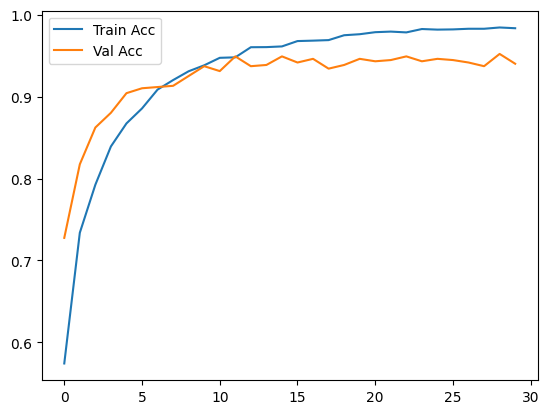

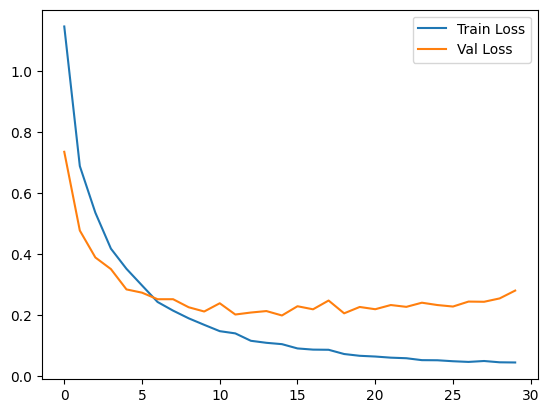

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


In [ ]:
model.save("dog_emotion_feature_classifier.h5")


In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_enc, axis=1)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


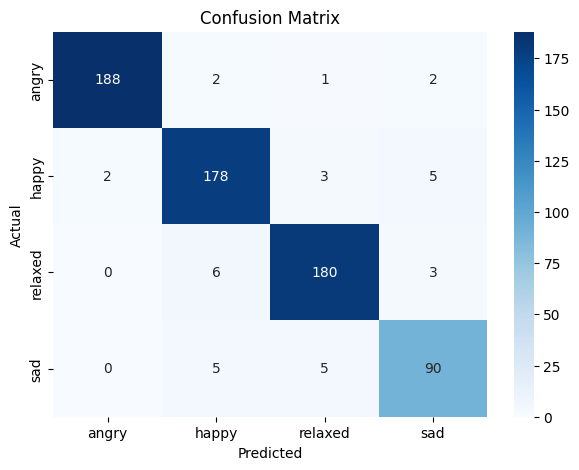

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
